# Comprehensive Gesture Recognition Dataset Analysis & Pipeline Walkthrough

Welcome to the central dataset analysis notebook! If you are a new data scientist starting on this project, this notebook will serve as your complete guide to the structure, composition, and physical recording pipeline of our gesture recognition datasets.

## Executive Summary
This project employs dual inertial measurement units (IMUs)—a wrist-worn sensor (`IMU1`) and a finger-mounted sensor (`IMU2`)—to recognize fine-grained and large-scale arm and hand movements.
Our dataset is categorized into three key versions:
* **Version 1**: Unfortunately lost due to an accidental deletion.
* **Version 2**: Archived at `data/dataset_v2_29-06-26/`.
* **Version 3**: Archived at `data/dataset_v3_30-06-26/`.
* **Current Active Version**: Stored in `data/dataset_current/`.

> **Important Limit / Bias Warning:** Up to `dataset_v3` (and the current version), the dataset has been entirely recorded by **one single subject** to save time and resources. While this is sufficient for a proof-of-concept (e.g. showcasing PowerPoint control at a presentation), the models will overfit to this specific individual's kinematics, hand size, and mounting alignments. Commercialization would require multi-subject data collection and Leave-One-Subject-Out (LOSO) cross-validation.

---

## The Data Recording Pipeline

To understand the structure of the dataset files on disk, we must look at how the data is recorded by `scripts/record_data.py`:

```
Hardware ESP32 IMUs -> Background Reader Threads -> thread-safe Queue -> Main Python Thread
```

### 1. Multi-threaded Asynchronous Acquisition
The ESP32 microcontrollers stream IMU data at a hardware-timed **100 Hz** rate (10ms interval) via USB-C serial interface. To prevent OS-level serial buffer overflows and eliminate I/O blocking from Python's main loop, the `IMUDataInput` module manages dedicated background reader threads for each serial port, pushing raw data into thread-safe queues.

### 2. Hidden Buffer Mechanism
Because the two ESP32 microcontrollers are initialized independently, their clock timelines do not match perfectly. To ensure that we capture a complete overlapping 1.5-second gesture window without clipping actual movement:
1. **Flush Queues**: Reader threads are drained to remove historical samples.
2. **Pre-Buffer**: The system records silently for `PRE_BUFFER_S = 0.15` seconds (15 samples).
3. **Active Recording (Progress Bar)**: The user is prompted via a CLI progress bar to perform the gesture for `RECORD_DURATION_S = 1.5` seconds (150 samples).
4. **Post-Buffer**: The system records silently for `POST_BUFFER_S = 0.15` seconds (15 samples).
This yields a raw capture of approximately **1.8 seconds (180 samples)**.

### 3. Temporal Alignment & Grid Resampling (`sync.py`)
Since PC arrival times and ESP32 clocks drift, `sync.py`:
* Aligns the timelines by calculating the median relative offset between the PC clock and the respective ESP32 clocks.
* Interpolates both sensors' data onto a strict, uniform **100 Hz grid** (10,000 $\mu$s period) using linear interpolation (`np.interp`).
* This merges the two streams into a unified DataFrame.

### 4. Centroid-Based Gesture Centering
Instead of hard-cropping the CSV to 150 samples immediately (which would make the dataset brittle to real-time temporal offsets), we save the **entire 1.8-second raw resampled segment** to a CSV file (e.g. `00001.csv`).
We then compute the **Instantaneous Motion Energy**:
$$E_i = |\|\mathbf{a}_{1,i}\|_2 - 1.0| + |\|\mathbf{a}_{2,i}\|_2 - 1.0| + 0.01 \cdot (\|\mathbf{g}_{1,i}\|_2 + \|\mathbf{g}_{2,i}\|_2)$$
The centroid index $\mu$ of this energy is calculated:
$$\mu = \frac{\sum_i i \cdot E_i}{\sum_i E_i}$$
The starting sample index $s$ of the 150-sample gesture window is selected to center around $\mu$:
$$s = \text{clip}\left(\text{round}\left(\mu - 75\right), 0, L - 150\right)$$
This start index $s$ is written to a companion text file (e.g. `00001.txt`).
* **Why do we do this?**
  * **Jitter Augmentation**: During model training, we can slice windows at $s \pm \text{jitter}$ (e.g. $\pm 25$ samples). This teaches the CNN translation invariance, making it robust to real-time delays!
  * **Context Preservation**: Keeping the pre- and post-gesture stillness allows us to test sliding-window triggers.

### 5. Periodic Recalibration
Gyroscopes experience drift. To keep calibration errors low, after a user records a block of **25 samples**, the pipeline automatically requests a new static calibration ($5.0$ seconds of stillness). This calibration is stored inside the session (e.g., `calibration_0.csv`, `calibration_1.csv`), and mapped in the metadata `recording_session.json` so the loader can apply the correct bias corrections.

---

## Setup and Dataset Traversal

Now let's load, inspect, and analyze our datasets programmatically! We will walk the directories inside `data/` and collect statistics for:
1. `dataset_v2_29-06-26`
2. `dataset_v3_30-06-26`
3. `dataset_current` (our active dataset)

Let's import our dependencies and write a helper function to analyze the directory structures.

In [1]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root and locate data directory
PROJECT_ROOT = Path(os.getcwd()).resolve()
if not (PROJECT_ROOT / "data").is_dir():
    # Walk up to find project root if notebook is run inside data_analysis/
    for parent in PROJECT_ROOT.parents:
        if (parent / "data").is_dir():
            PROJECT_ROOT = parent
            break

DATA_ROOT = PROJECT_ROOT / "data"
print(f"Project root resolved to: {PROJECT_ROOT}")
print(f"Data root resolved to: {DATA_ROOT}")

Project root resolved to: /Users/jantischner/Library/CloudStorage/OneDrive-Personal/TH_OHM_B.Sc.Inf/Th-Ohm_B.Sc.Inf_Sem6/DatFus_Sem6_Axenie/DataFusionProject
Data root resolved to: /Users/jantischner/Library/CloudStorage/OneDrive-Personal/TH_OHM_B.Sc.Inf/Th-Ohm_B.Sc.Inf_Sem6/DatFus_Sem6_Axenie/DataFusionProject/data


In [2]:
def analyze_dataset_structure(dataset_path: Path):
    """
    Recursively scans a dataset directory to extract structured metrics.
    """
    if not dataset_path.exists():
        print(f"Warning: Directory {dataset_path} does not exist.")
        return None
        
    gestures = [p.name for p in dataset_path.iterdir() if p.is_dir() and not p.name.startswith('.')]
    
    dataset_stats = {
        "dataset_name": dataset_path.name,
        "gestures": sorted(gestures),
        "total_sessions": 0,
        "total_samples": 0,
        "total_calibrations": 0,
        "session_details": [],
        "sample_lengths": [],
        "start_indices": [],
    }
    
    for gesture in gestures:
        gesture_dir = dataset_path / gesture
        sessions = [p for p in gesture_dir.iterdir() if p.is_dir() and not p.name.startswith('.')]
        dataset_stats["total_sessions"] += len(sessions)
        
        for session in sessions:
            session_name = session.name
            csv_files = sorted(list(session.glob("*.csv")))
            # Filter out calibration csvs and energy distributions
            sample_csvs = [f for f in csv_files if f.stem.isdigit() and len(f.stem) == 5]
            cal_csvs = [f for f in csv_files if f.name.startswith("calibration_")]
            
            sample_count = len(sample_csvs)
            cal_count = len(cal_csvs)
            
            dataset_stats["total_samples"] += sample_count
            dataset_stats["total_calibrations"] += cal_count
            
            # Read start indices and sample shapes
            for sample_csv in sample_csvs:
                # Length
                try:
                    df = pd.read_csv(sample_csv)
                    dataset_stats["sample_lengths"].append(len(df))
                except Exception:
                    pass
                
                # Start index companion
                txt_file = sample_csv.with_suffix('.txt')
                if txt_file.exists():
                    try:
                        with open(txt_file, 'r') as f:
                            idx = int(f.read().strip())
                            dataset_stats["start_indices"].append(idx)
                    except Exception:
                        pass
            
            # Read metadata if exists
            metadata_file = session / "recording_session.json"
            participant_id = "unknown"
            if metadata_file.exists():
                try:
                    with open(metadata_file, 'r') as f:
                        meta = json.load(f)
                        participant_id = meta.get("participant_id", "p01")
                except Exception:
                    pass
            
            dataset_stats["session_details"].append({
                "gesture": gesture,
                "session_name": session_name,
                "sample_count": sample_count,
                "calibration_count": cal_count,
                "participant_id": participant_id
            })
            
    return dataset_stats

In [3]:
# Analyze all existing versions
datasets_to_analyze = [
    "dataset_v2_29-06-26",
    "dataset_v3_30-06-26",
    "dataset_current"
]

results = {}
for ds_name in datasets_to_analyze:
    path = DATA_ROOT / ds_name
    print(f"Scanning {ds_name}...")
    stats = analyze_dataset_structure(path)
    if stats:
        results[ds_name] = stats

Scanning dataset_v2_29-06-26...


Scanning dataset_v3_30-06-26...


Scanning dataset_current...


## Comparative Summary Table
This table provides a high-level quantitative comparison across all dataset versions. It is the first checkpoint for understanding dataset growth and overall recording effort.
**Columns explained:**
* **Total Classes**: Number of distinct gesture categories. All versions maintain 8 classes (`none`, `swipe_left`, `swipe_right`, `circle_cw`, `circle_ccw`, `fist`, `jerk_down`, `jerk_up`).
* **Total Sessions**: Total number of independent recording sessions across all classes. Each session represents a physical mounting/calibration event — more sessions means the model will see more variance in sensor alignment, hand position, and cable tension.
* **Total Samples**: Total number of gesture windows recorded across all classes.
* **Total Calibrations**: Number of 5-second static calibration captures. Calibrations are triggered every 25 recordings to compensate for gyroscope bias drift (see `record_data.py` and the [Data Recording Pipeline documentation](../documentation/data_recording_pipeline.md)).
* **Avg Samples/Class**: Indicates class balance. A perfectly balanced dataset has equal counts across all classes. Significant deviations indicate potential class imbalance that could bias the classifier.
* **Avg Samples/Session**: Measures session density. Higher values mean more gestures were recorded per mounting, which reduces inter-session variance. Lower values (with more sessions) increase generalization.
* **Avg Raw Length (samples)**: Average number of rows in the raw CSV files (before centroid cropping to 150 samples). Values near 170 confirm the hidden pre-buffer (15 samples) + active recording (150 samples) + post-buffer (15 samples) = ~180 expected samples, with minor losses due to serial stream synchronization.
**Key Observations:**
* `dataset_v2` has fewer sessions (14) and significantly fewer samples (749) than `dataset_v3` and `dataset_current` (both 1,600 samples, 23 sessions).
* The average raw CSV length is ~170 samples in all versions, confirming the hidden buffer mechanism is functioning as designed.
* `dataset_v3` and `dataset_current` have identical sample counts and session structures — `dataset_current` is derived from `dataset_v3` after data cleaning and format standardization.

In [4]:
summary_data = []
for ds_name, stats in results.items():
    summary_data.append({
        "Dataset Version": ds_name,
        "Total Classes": len(stats["gestures"]),
        "Total Sessions": stats["total_sessions"],
        "Total Samples": stats["total_samples"],
        "Total Calibrations": stats["total_calibrations"],
        "Avg Samples/Class": round(stats["total_samples"] / len(stats["gestures"]), 1) if stats["gestures"] else 0,
        "Avg Samples/Session": round(stats["total_samples"] / stats["total_sessions"], 1) if stats["total_sessions"] else 0,
        "Avg Raw Length (samples)": round(np.mean(stats["sample_lengths"]), 1) if stats["sample_lengths"] else 0,
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,Dataset Version,Total Classes,Total Sessions,Total Samples,Total Calibrations,Avg Samples/Class,Avg Samples/Session,Avg Raw Length (samples)
0,dataset_v2_29-06-26,8,14,749,22,93.6,53.5,171.0
1,dataset_v3_30-06-26,8,23,1600,57,200.0,69.6,169.8
2,dataset_current,8,23,1600,57,200.0,69.6,169.8


## Visualization 1: Class Distribution per Dataset Version

**Purpose:** This grouped bar chart visualizes the number of gesture samples recorded per class for each dataset version. It is the primary tool for detecting **class imbalance** — a critical issue in gesture classification that can silently degrade model performance.

**Why it matters for data understanding:**
* **Class Imbalance Detection**: If one class has significantly fewer samples than others, the classifier will struggle to learn its decision boundary. For example, if `circle_cw` has 50% fewer samples than `swipe_right`, the model may develop a systematic bias toward the majority class, resulting in poor recall for the under-represented gesture.
* **Version Evolution Tracking**: Comparing `dataset_v2` → `dataset_v3` → `dataset_current` reveals how the data collection effort progressed. A well-designed data collection campaign should show approximately equal growth across all classes.
* **None-Class Weighting**: The `none` class is particularly critical. It must have sufficient samples to prevent false positives during real-time inference (where the sensor is idle 90%+ of the time). An under-represented `none` class leads to excessive false gesture triggers during normal hand movement.

**What to look for:**
* All bars within a dataset version should be roughly equal height (balanced dataset).
* The `none` class should have at least as many samples as the most populated active gesture class.
* `dataset_v2` bars should be consistently shorter than `dataset_v3`/`dataset_current` bars (confirming the data collection expansion).


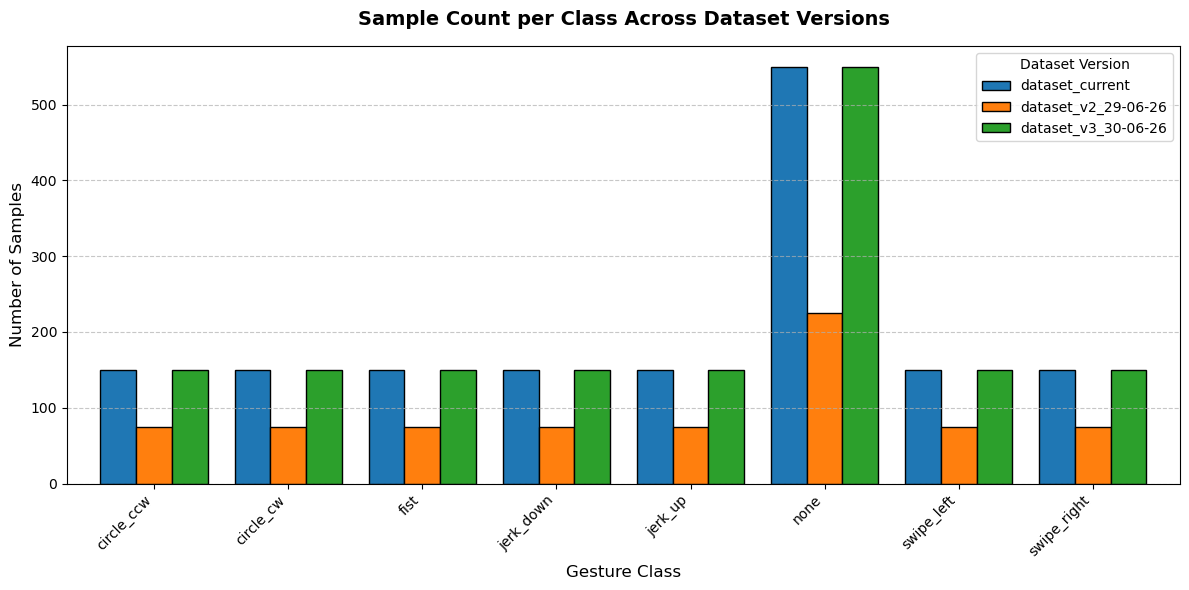

In [5]:
class_data = []
for ds_name, stats in results.items():
    counts = {g: 0 for g in stats["gestures"]}
    for detail in stats["session_details"]:
        counts[detail["gesture"]] += detail["sample_count"]
    for g, count in counts.items():
        class_data.append({"dataset": ds_name, "class": g, "samples": count})

df_class = pd.DataFrame(class_data)

plt.figure(figsize=(12, 6))
pivot_df = df_class.pivot(index="class", columns="dataset", values="samples").fillna(0)
pivot_df.plot(kind="bar", width=0.8, ax=plt.gca(), edgecolor='black')

plt.title("Sample Count per Class Across Dataset Versions", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Gesture Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Dataset Version", fontsize=10)
plt.tight_layout()
plt.show()

## Visualization 2: Recording Sessions per Class

**Purpose:** This grouped bar chart shows how many **independent recording sessions** were conducted for each gesture class across dataset versions. While Visualization 1 shows total sample counts, this chart reveals the **diversity of recording conditions** — a fundamentally different and equally important metric.

**Why it matters for data understanding:**
* **Inter-Session Variance**: Each recording session represents a unique physical configuration: the sensor boards are re-mounted on the glove, the USB cables may hang differently, the hand may be positioned at a slightly different starting angle, and a fresh gyroscope calibration is performed. Training on samples from many sessions forces the model to learn gesture dynamics that generalize across these physical variations.
* **Leave-Session-Out Cross-Validation**: Our model training pipeline uses Leave-Session-Out (LSO) splits (see [Model Training Pipeline](../documentation/model_training_pipeline.md)). If a class has only 1–2 sessions, the LSO validation fold for that class will have almost no held-out data, making the validation accuracy unreliable.
* **Overfitting Risk**: A class with many samples but few sessions (e.g., 200 samples from 2 sessions) is at high risk of overfitting to the specific sensor alignment and calibration state of those 2 sessions. Conversely, 200 samples from 8 sessions provides much better generalization.

**What to look for:**
* All classes should ideally have ≥3 sessions per dataset version.
* Session counts should grow proportionally across versions (no class should be "stuck" at 1 session while others grow).
* Any class with only 1 session in the active dataset is a data quality risk — it needs more recording sessions before the model can be trusted for that gesture.


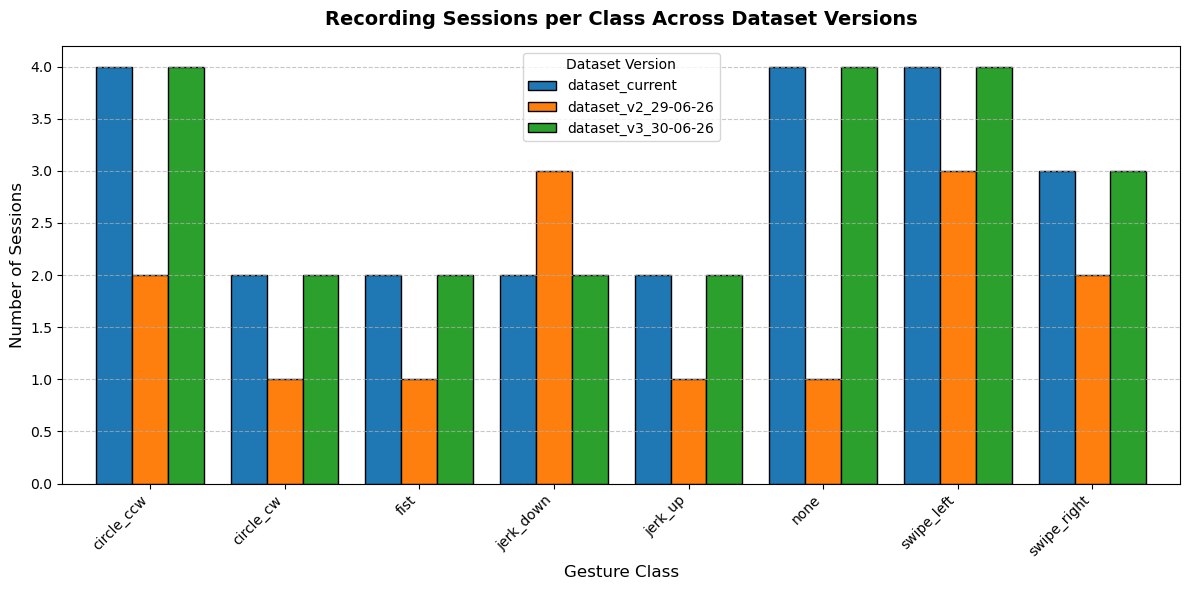

In [6]:
session_counts = []
for ds_name, stats in results.items():
    counts = {g: 0 for g in stats["gestures"]}
    for detail in stats["session_details"]:
        counts[detail["gesture"]] += 1
    for g, count in counts.items():
        session_counts.append({"dataset": ds_name, "class": g, "sessions": count})

df_sess = pd.DataFrame(session_counts)

plt.figure(figsize=(12, 6))
pivot_sess = df_sess.pivot(index="class", columns="dataset", values="sessions").fillna(0)
pivot_sess.plot(kind="bar", width=0.8, ax=plt.gca(), edgecolor='black')

plt.title("Recording Sessions per Class Across Dataset Versions", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Number of Sessions", fontsize=12)
plt.xlabel("Gesture Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Dataset Version", fontsize=10)
plt.tight_layout()
plt.show()

## Visualization 3: Distribution of Samples per Session

**Purpose:** This box plot visualizes the **statistical distribution of how many gesture iterations were recorded within each individual session**. It answers: "When we sit down to record a session, how many gestures do we typically capture before ending or recalibrating?"

**Why it matters for data understanding:**
* **Session Density Uniformity**: If some sessions have 100+ samples and others have only 5, the dataset has high variance in session density. This creates an implicit bias — the model will be disproportionately trained on the physical conditions (sensor alignment, hand posture, calibration state) of the high-density sessions.
* **Calibration Interval Validation**: The recording pipeline triggers a gyroscope recalibration every 25 samples. Therefore, we expect the median session size to cluster around multiples of 25 (±5). Significant deviations suggest the recording was interrupted early (operator fatigue, sensor disconnection) or the calibration interval was different in older dataset versions.
* **Outlier Detection**: Extremely short sessions (< 5 samples) may indicate aborted recordings. Extremely long sessions (> 100 samples) may indicate that recalibration was not performed, risking gyroscope drift contamination in later samples.

**What to look for:**
* The box (interquartile range) should be relatively tight, centered around 25–75 samples.
* Whiskers extending below 10 suggest aborted sessions that may need manual review.
* `dataset_v2` may show higher variance (less standardized recording protocol) compared to `dataset_v3`/`dataset_current`.


/var/folders/sk/xzcrplr925n07p_wdvs03n3w0000gn/T/ipykernel_32515/180473104.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=datasets, patch_artist=True,


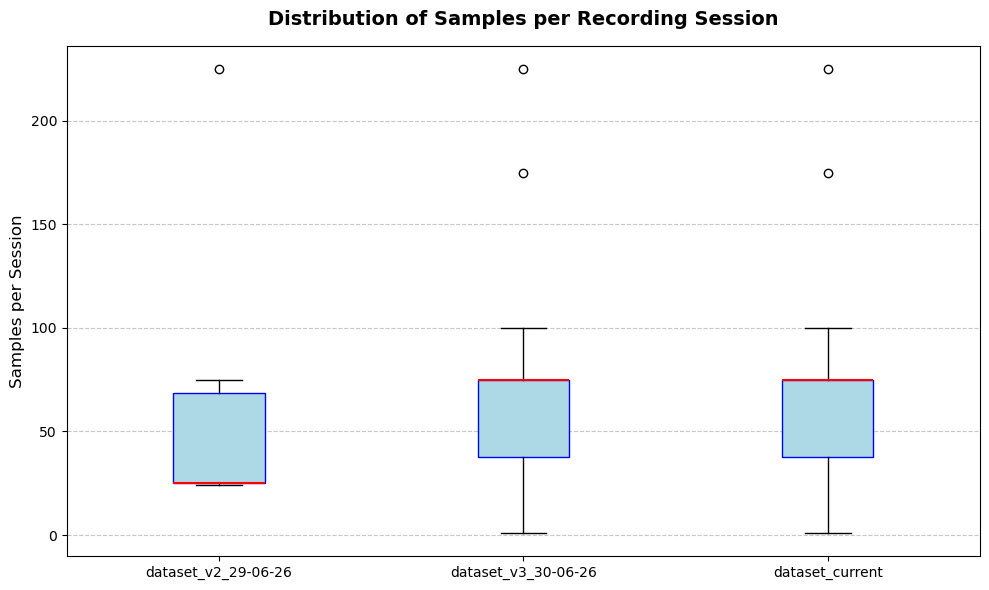

In [7]:
session_samples_data = []
for ds_name, stats in results.items():
    for detail in stats["session_details"]:
        session_samples_data.append({
            "dataset": ds_name,
            "session": detail["session_name"],
            "sample_count": detail["sample_count"]
        })
        
df_sess_samples = pd.DataFrame(session_samples_data)

plt.figure(figsize=(10, 6))
datasets = df_sess_samples["dataset"].unique()
plot_data = [df_sess_samples[df_sess_samples["dataset"] == ds]["sample_count"].values for ds in datasets]

plt.boxplot(plot_data, labels=datasets, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=1.5))

plt.title("Distribution of Samples per Recording Session", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Samples per Session", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualization 4: Calibration Counts per Session

**Purpose:** This box plot shows the number of **static calibration captures** (5-second stillness periods) that were performed within each recording session, across dataset versions. It directly measures the frequency of **gyroscope bias drift compensation**.

**Why it matters for data understanding:**
* **Gyroscope Drift Compensation**: MEMS gyroscopes (like the BMI270 on our XIAO ESP32-S3 boards) suffer from zero-rate offset drift. Over the course of a multi-minute recording session, the accumulated bias can shift the gyroscope baseline by several deg/s. Static calibrations subtract this drift by measuring the gyroscope output during known-stillness periods and computing a bias correction vector.
* **Calibration Frequency vs. Data Quality**: The recording pipeline requests a new calibration every 25 samples (see `RECAL_INTERVAL = 25` in `scripts/record_data.py`). If the median calibration count is low (e.g., 0–1 per session), the samples recorded after the first 25 gestures may have degraded gyroscope accuracy.
* **Dataset Version Comparison**: `dataset_v2` was recorded with a less rigorous protocol — the calibration interval may not have been enforced. `dataset_v3`/`dataset_current` should show higher and more consistent calibration counts.

**What to look for:**
* For `dataset_v3`/`dataset_current`: $\text{calibrations} \approx \lceil \text{samples} / 25 \rceil$ (at least 1 calibration per 25 gesture recordings).
* `dataset_v2` may show sessions with 0 calibrations — these sessions have higher gyroscope drift risk.
* A tight box (low IQR) indicates consistent recording discipline.

/var/folders/sk/xzcrplr925n07p_wdvs03n3w0000gn/T/ipykernel_32515/1576232396.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_cal_data, labels=datasets, patch_artist=True,


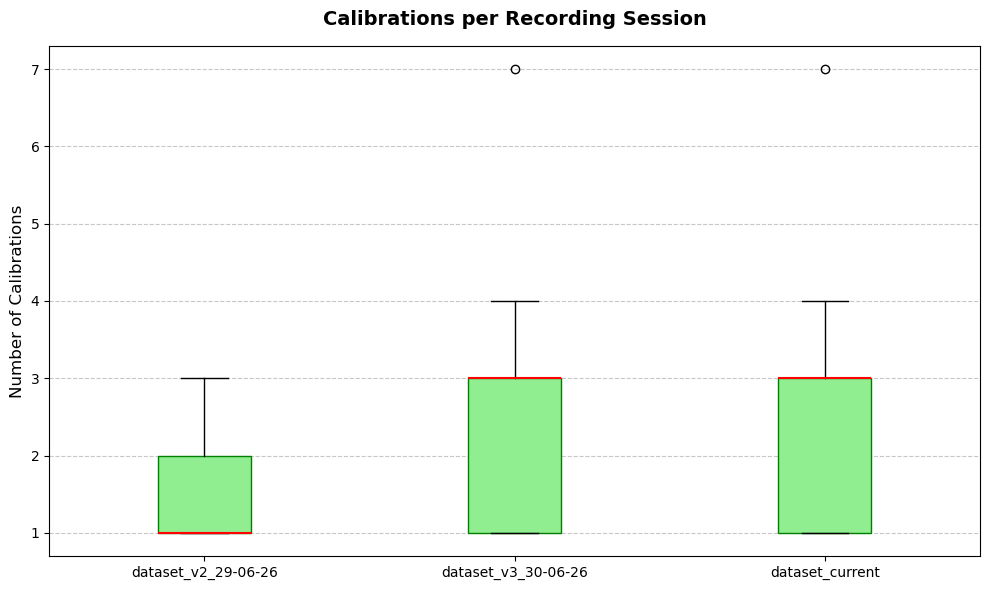

In [8]:
cal_data = []
for ds_name, stats in results.items():
    for detail in stats["session_details"]:
        cal_data.append({
            "dataset": ds_name,
            "session": detail["session_name"],
            "cal_count": detail["calibration_count"]
        })

df_cal = pd.DataFrame(cal_data)

plt.figure(figsize=(10, 6))
datasets = df_cal["dataset"].unique()
plot_cal_data = [df_cal[df_cal["dataset"] == ds]["cal_count"].values for ds in datasets]

plt.boxplot(plot_cal_data, labels=datasets, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='green'),
            medianprops=dict(color='red', linewidth=1.5))

plt.title("Calibrations per Recording Session", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Number of Calibrations", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualization 5: Centroid Start Index Distribution

**Purpose:** This histogram visualizes the distribution of the **centroid-based start indices** stored in the `.txt` companion files. Each `.txt` file contains a single integer: the sample index $s$ within the raw ~170-sample CSV where the 150-sample gesture window begins. This is the most critical diagnostic for understanding the **temporal centering** of our dataset.

**Why it matters for data understanding:**
* **Centroid-Based Gesture Centering**: The recording pipeline does not blindly crop the first 150 samples. Instead, it computes the Instantaneous Motion Energy:
$$E_i = |\|\mathbf{a}_{1,i}\|_2 - 1.0| + |\|\mathbf{a}_{2,i}\|_2 - 1.0| + 0.01 \cdot (\|\mathbf{g}_{1,i}\|_2 + \|\mathbf{g}_{2,i}\|_2)$$
  and calculates the energy centroid $\mu = \frac{\sum_i i \cdot E_i}{\sum_i E_i}$. The start index is then $s = \text{clip}(\text{round}(\mu - 75), 0, L - 150)$.
* **Jitter Augmentation Validation**: During training, the pipeline applies temporal jitter by sampling windows at $s + \delta$ where $\delta \sim \text{Uniform}(-\text{jitter\_range}, +\text{jitter\_range})$. For this augmentation to work, the start index $s$ must not be at the extreme boundaries (0 or $L - 150$), otherwise the jittered window would clip. A healthy distribution should have $s$ concentrated in the range $[5, 25]$, leaving room for $\pm 5$ to $\pm 15$ jitter.
* **Recording Timing Quality**: If the histogram is heavily skewed toward $s = 0$, it means the gesture motion started before the pre-buffer captured it (the user moved too early). If skewed toward $s = L - 150$, the motion happened too late. A centered, unimodal distribution around $s \approx 10$–$15$ confirms that the hidden buffer mechanism and user prompts are working correctly.

**What to look for:**
* The histogram should be unimodal, centered around $s \in [5, 20]$.
* Very few or no samples at $s = 0$ (boundary clip) — would indicate pre-buffer was too short.
* The distribution shape should be similar across `dataset_v2`, `dataset_v3`, and `dataset_current` (consistent recording protocol).


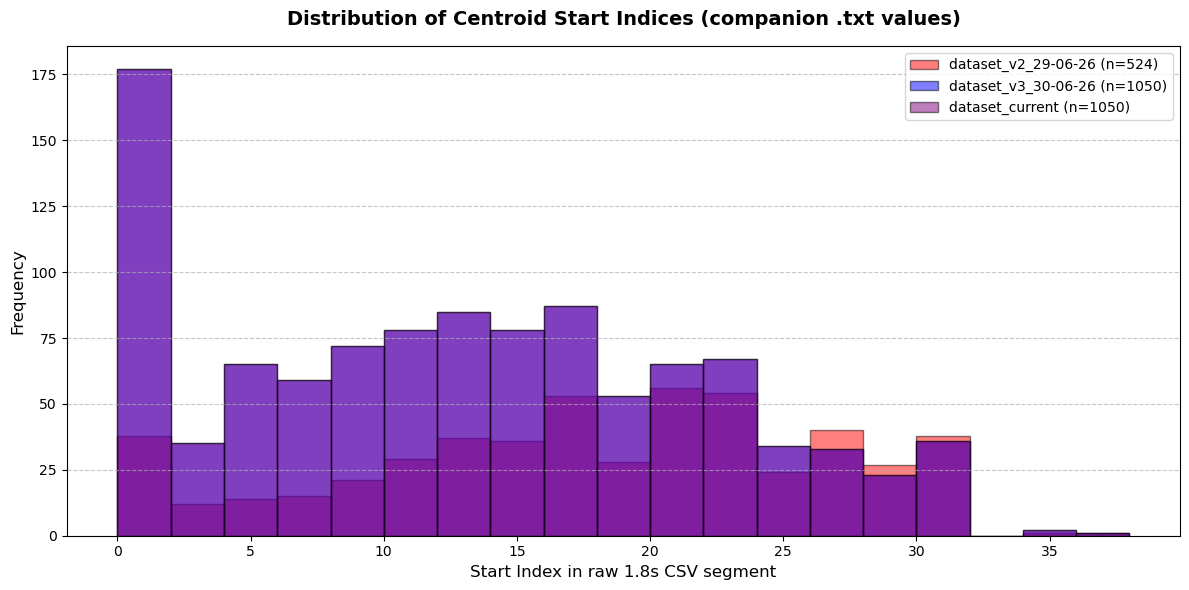

In [9]:
plt.figure(figsize=(12, 6))
colors = {"dataset_v2_29-06-26": "red", "dataset_v3_30-06-26": "blue", "dataset_current": "purple"}

for ds_name, stats in results.items():
    indices = stats["start_indices"]
    if indices:
        plt.hist(indices, bins=np.arange(0, 40, 2), alpha=0.5, 
                 label=f"{ds_name} (n={len(indices)})", 
                 color=colors.get(ds_name, "grey"), edgecolor='black')

plt.title("Distribution of Centroid Start Indices (companion .txt values)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Start Index in raw 1.8s CSV segment", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Analysis of Gesture Motion Energy Centering (Case Study)

**Purpose:** This case study plot provides a **visual proof** of the centroid-based gesture centering mechanism by loading a single raw CSV sample, computing its Instantaneous Motion Energy time series, and overlaying the selected 150-sample CNN window.

**Why it matters for data understanding:**
* **Visual Validation of the Centering Algorithm**: The orange motion energy curve should show a clear energy peak during the gesture movement. The blue shaded region (the selected 150-sample window) should be centered around this peak. If the blue region misses the peak, the centroid algorithm has a bug.
* **Pre/Post Stillness Context**: The raw CSV extends ~15 samples before and after the blue region. This "context" is the hidden pre-buffer and post-buffer captured during recording. The energy in these buffer zones should be near-zero (hand held still). If significant motion energy exists outside the blue region, the gesture was not fully captured.
* **Jitter Range Feasibility**: The gap between the blue region's left edge and the CSV's start (i.e., the start index $s$) represents the available room for negative jitter augmentation during training. Similarly, the gap between the blue region's right edge and the CSV's end is the room for positive jitter. Both gaps should be at least 5–15 samples for the default `jitter_range = 5` to `15` to work without boundary clipping.

**Energy formula used:**
$$E_i = |\|\mathbf{a}_{1,i}\|_2 - 1.0| + |\|\mathbf{a}_{2,i}\|_2 - 1.0| + 0.01 \cdot (\|\mathbf{g}_{1,i}\|_2 + \|\mathbf{g}_{2,i}\|_2)$$

Where $\mathbf{a}_{k,i}$ is the 3-axis accelerometer vector of IMU $k$ at sample $i$, and $\mathbf{g}_{k,i}$ is the 3-axis gyroscope vector. The accelerometer contribution dominates (gravity-subtracted magnitude), with a small gyroscope weighting to detect rotational-only gestures (e.g., `circle_cw`, `circle_ccw`).

**What to look for:**
* A clear, localized energy peak within the blue shaded window.
* Near-zero energy in the buffer regions flanking the blue window.
* The blue dashed vertical lines should bracket the energy peak symmetrically (centroid centering).


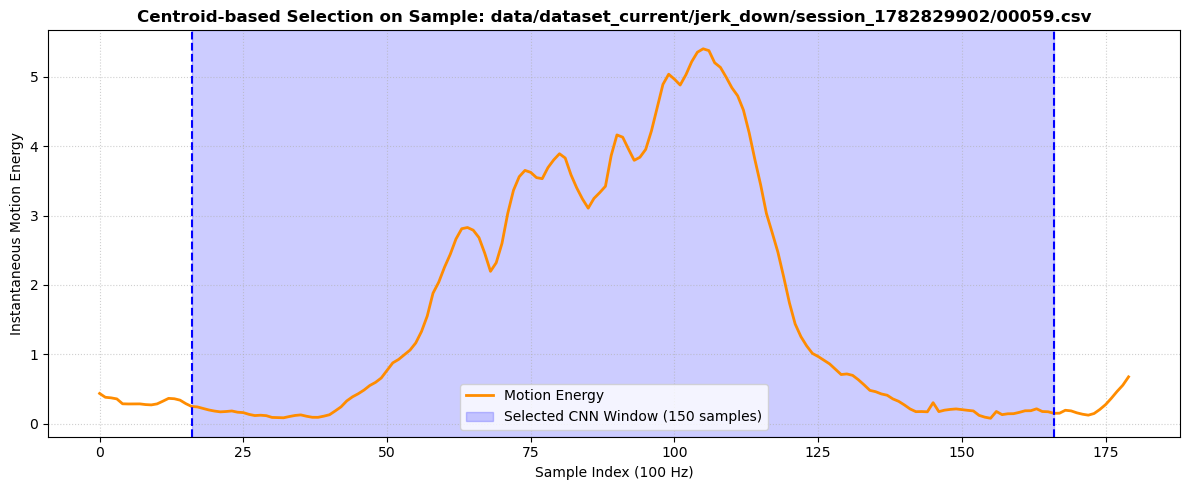

In [10]:
# Find a sample file in dataset_current to plot
sample_file = None
for root, dirs, files in os.walk(DATA_ROOT / "dataset_current"):
    for f in files:
        if f.endswith('.csv') and f.split('.')[0].isdigit() and len(f.split('.')[0]) == 5:
            sample_file = Path(root) / f
            break
    if sample_file:
        break

if sample_file and sample_file.exists():
    df = pd.read_csv(sample_file)
    txt_file = sample_file.with_suffix('.txt')
    start_idx = 0
    if txt_file.exists():
        with open(txt_file, 'r') as f:
            start_idx = int(f.read().strip())
            
    # Calculate motion energy
    acc1_cols = [c for c in df.columns if c.startswith("IMU1_acc")]
    acc2_cols = [c for c in df.columns if c.startswith("IMU2_acc")]
    gyr1_cols = [c for c in df.columns if c.startswith("IMU1_gyr")]
    gyr2_cols = [c for c in df.columns if c.startswith("IMU2_gyr")]
    
    if acc1_cols and acc2_cols:
        acc1_mag = np.linalg.norm(df[acc1_cols].values, axis=1)
        acc2_mag = np.linalg.norm(df[acc2_cols].values, axis=1)
        gyr1_mag = np.linalg.norm(df[gyr1_cols].values, axis=1) if gyr1_cols else np.zeros(len(df))
        gyr2_mag = np.linalg.norm(df[gyr2_cols].values, axis=1) if gyr2_cols else np.zeros(len(df))
        
        energy = np.abs(acc1_mag - 1.0) + np.abs(acc2_mag - 1.0) + 0.01 * (gyr1_mag + gyr2_mag)
        
        # Plot
        plt.figure(figsize=(12, 5))
        plt.plot(energy, label="Motion Energy", color='darkorange', linewidth=2)
        
        # Highlight cropped window
        plt.axvspan(start_idx, start_idx + 150, alpha=0.2, color='blue', label="Selected CNN Window (150 samples)")
        plt.axvline(start_idx, color='blue', linestyle='--', linewidth=1.5)
        plt.axvline(start_idx + 150, color='blue', linestyle='--', linewidth=1.5)
        
        plt.title(f"Centroid-based Selection on Sample: {sample_file.relative_to(PROJECT_ROOT)}", fontsize=12, fontweight="bold")
        plt.xlabel("Sample Index (100 Hz)", fontsize=10)
        plt.ylabel("Instantaneous Motion Energy", fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Required columns for IMU1 and IMU2 not found in the sample DataFrame.")
else:
    print("No sample file found in dataset_current for visualization case study.")